# Problem Definition

Given borrower attributes, predict whether their loan will be "Charged off" (i.e. default) or "Fully Paid", and, for approved loans, recommend repayment terms.

Key Objectives:
- Minimize false positives (approving loans that default) to reduce NPAs.
- Maximize true positives (approving loans that are repaid).
- Provide business recommendations for repayment terms.

# Exploratory Data Analysis

## Importing Libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, f1_score, confusion_matrix
from IPython.display import display
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

## Load and Inspect data

In [2]:
df = pd.read_csv('/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/LoanTap- Logistic Regression/logistic_regression.csv')

In [3]:
display(df.head())

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


## Data Structure and Characteristics

In [4]:
print('Shape:', df.shape)

Shape: (396030, 27)


In [5]:
print(df.dtypes)

loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
address                  object
dtype: object


Insights

- Shape: 3,96,030 rows and 27 columns.
- Types: floats for numeric, objects for categoricals and free-text (eg: emp_title, title, address).

## Statistical Summary and Missing Values

In [6]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
dtype: int64


Insights
- emp_title (23K missing), emp_length (18K), and a handful in public records fields.
- Will drop free text columns and impute the rest to zero.

## Univariate Analysis

### Continous Features

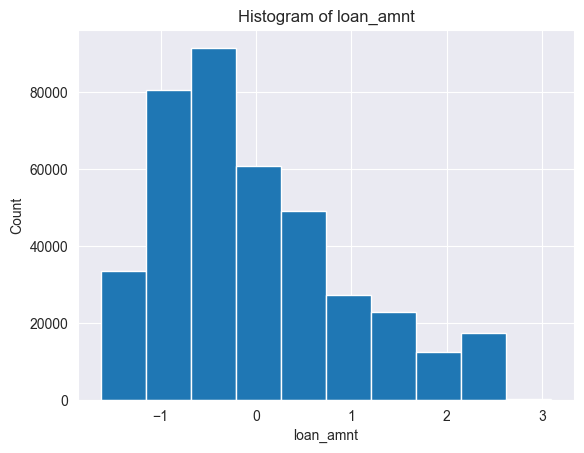

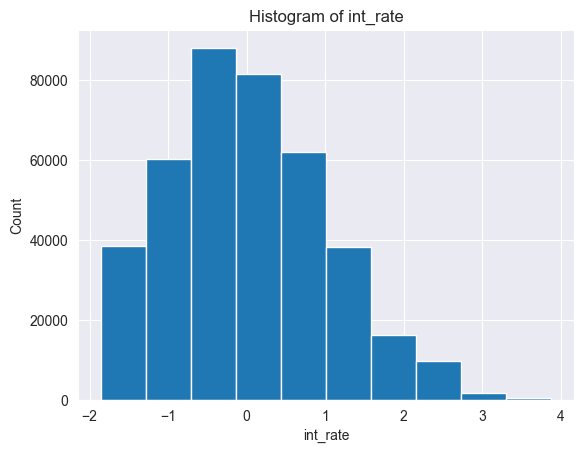

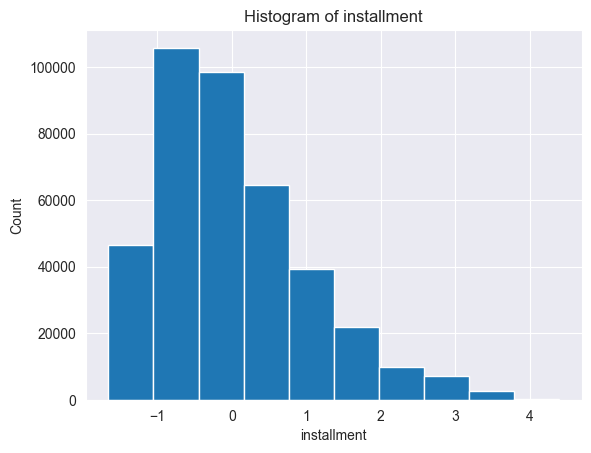

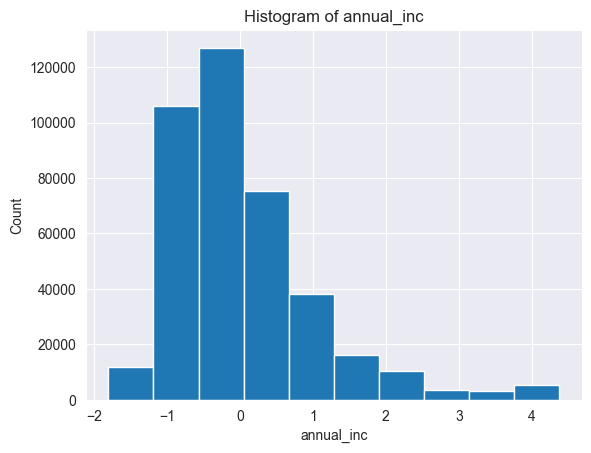

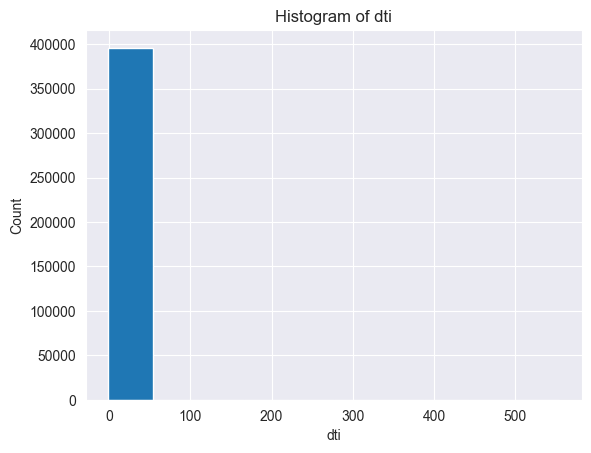

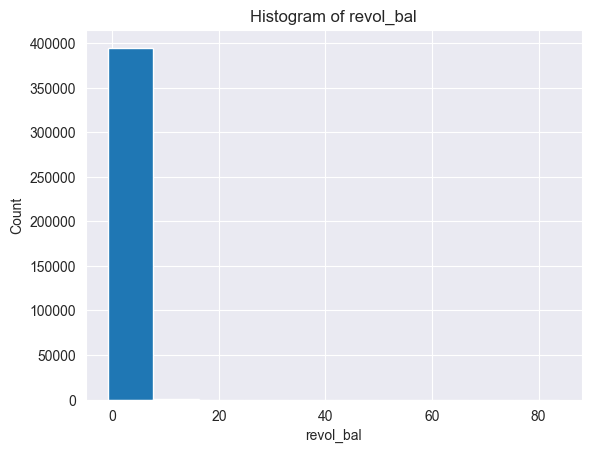

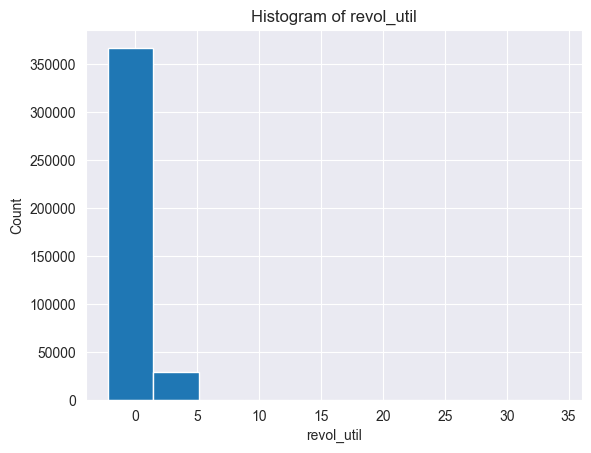

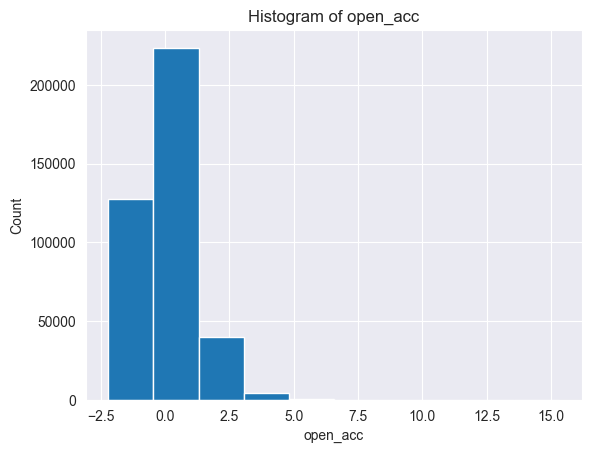

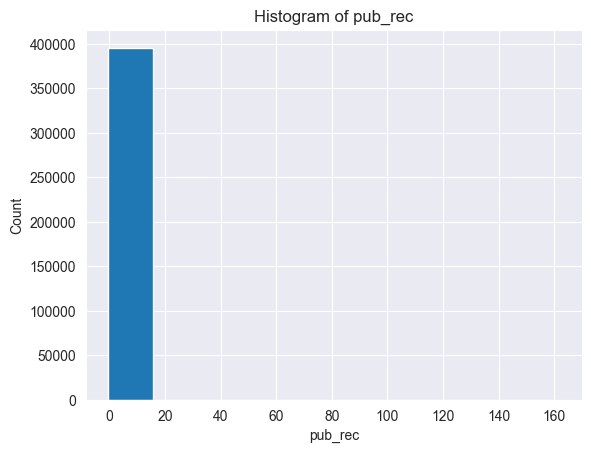

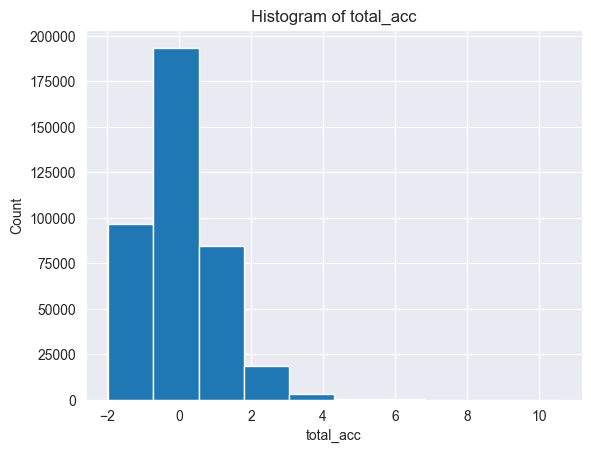

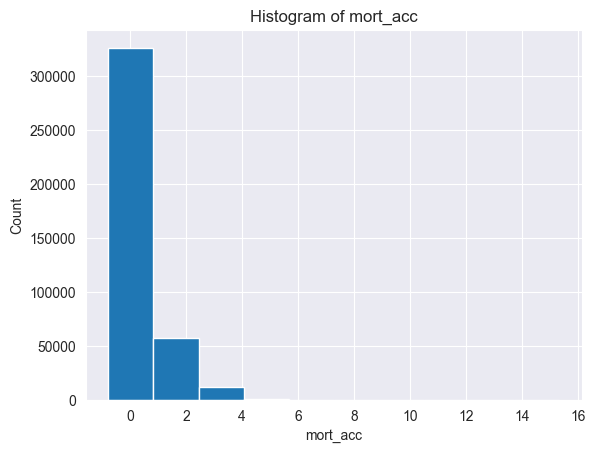

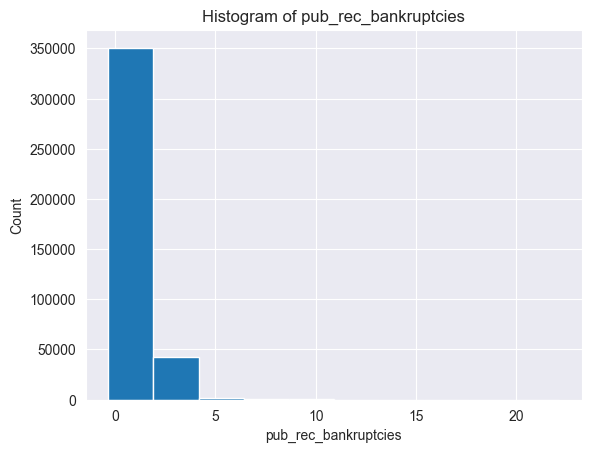

In [90]:
# Input Data Distribution

continous = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

for col in continous:
    plt.figure()
    df[col].hist()
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [92]:
for col in continous:
    desc = df[col].describe()
    skew = df[col].skew()
    print(f"\n{col}:")
    print(f"  Min={desc['min']:.2f}, Q1={desc['25%']:.2f}, Median={desc['50%']:.2f}, Q3={desc['75%']:.2f}, Max={desc['max']:.2f}, Skew={skew:.2f}")


loan_amnt:
  Min=-1.63, Q1=-0.73, Median=-0.25, Q3=0.70, Max=3.10, Skew=0.78

int_rate:
  Min=-1.86, Q1=-0.70, Median=-0.07, Q3=0.64, Max=3.88, Skew=0.42

installment:
  Min=-1.66, Q1=-0.72, Median=-0.23, Q3=0.54, Max=4.40, Skew=0.98

annual_inc:
  Min=-1.80, Q1=-0.69, Median=-0.22, Q3=0.42, Max=4.37, Skew=1.74

dti:
  Min=-0.96, Q1=-0.34, Median=-0.03, Q3=0.31, Max=553.95, Skew=431.05

revol_bal:
  Min=-0.77, Q1=-0.48, Median=-0.23, Q3=0.18, Max=83.89, Skew=11.73

revol_util:
  Min=-2.20, Q1=-0.73, Median=0.04, Q3=0.78, Max=34.25, Skew=-0.07

open_acc:
  Min=-2.20, Q1=-0.64, Median=-0.26, Q3=0.52, Max=15.32, Skew=1.21

pub_rec:
  Min=-0.34, Q1=-0.34, Median=-0.34, Q3=-0.34, Max=161.72, Skew=16.58

total_acc:
  Min=-1.97, Q1=-0.71, Median=-0.12, Q3=0.55, Max=10.56, Skew=0.86

mort_acc:
  Min=-0.78, Q1=-0.78, Median=-0.30, Q3=0.64, Max=15.33, Skew=1.71

pub_rec_bankruptcies:
  Min=-0.34, Q1=-0.34, Median=-0.34, Q3=-0.34, Max=22.13, Skew=3.43


Insights
- loan_amnt: Most loans are betwen 5K-20K, few high values loans skew distribution - Right sided.
- int_rate: Majority lie between 10-15%, right skewed.
- installment: Common EMIs range from 200-600, follows loan trend.
- annual_inc: String right skew, few very high income outliers.
- dti: Most values are near 0, extreme outliers present.
- revol_bal: Concentrated below 200K, few very high values.
- revol_util: Mostly under 100%, some unrealistically high values (>800%).

In [9]:
# Target variable distribution
fully_paid_count = df['loan_status'].value_counts().get('Fully Paid', 0)
print(f"Fully Paid: {(fully_paid_count / len(df)) * 100:.2f}%")

Fully Paid: 80.39%


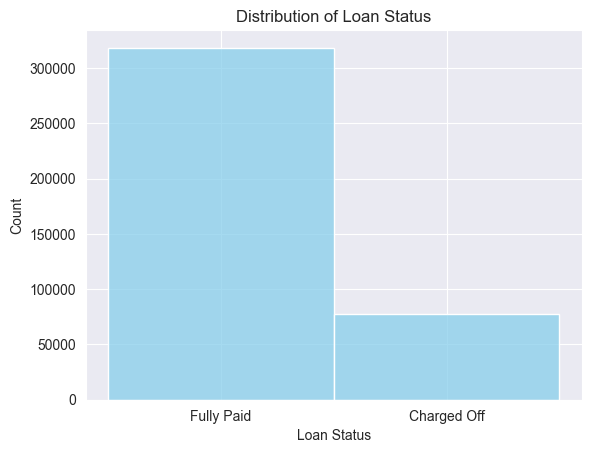

In [10]:
sns.histplot(df['loan_status'], color = 'skyblue')
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

Insights:
- Fully paid loans: 80.39% indicates most borrowers repay on time.
- Charged off loans: ~19.6% suggests a moderate level of loan defaults.
- Class imbalance is present - important to address in model building

### Categorical Features

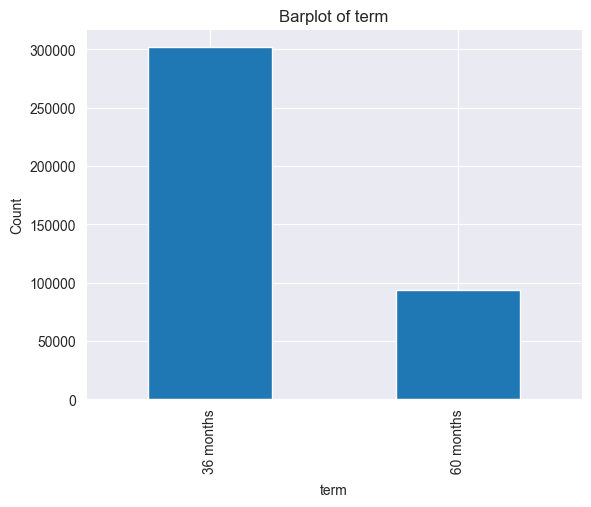

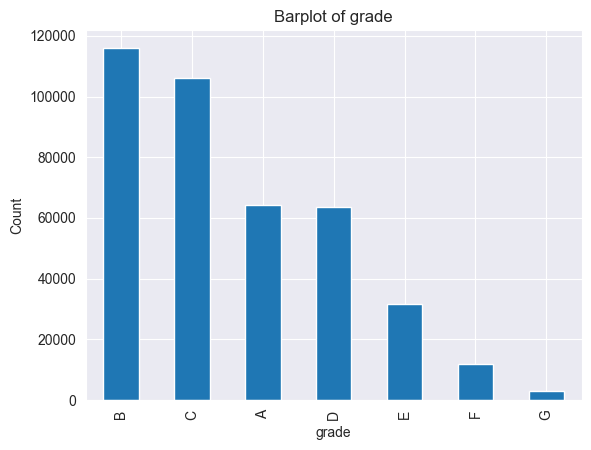

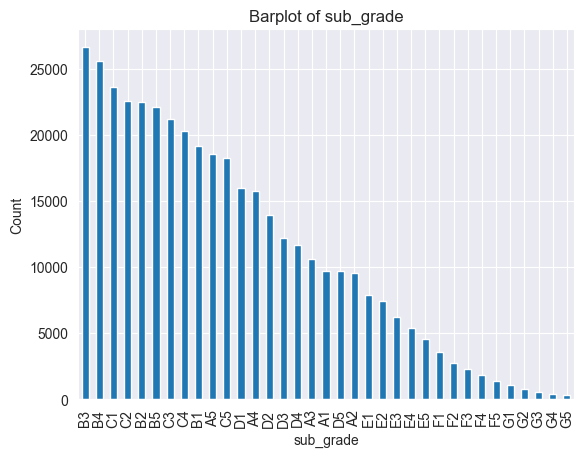

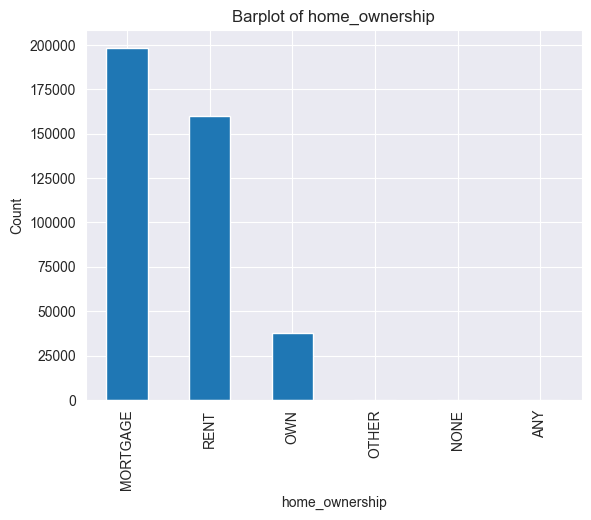

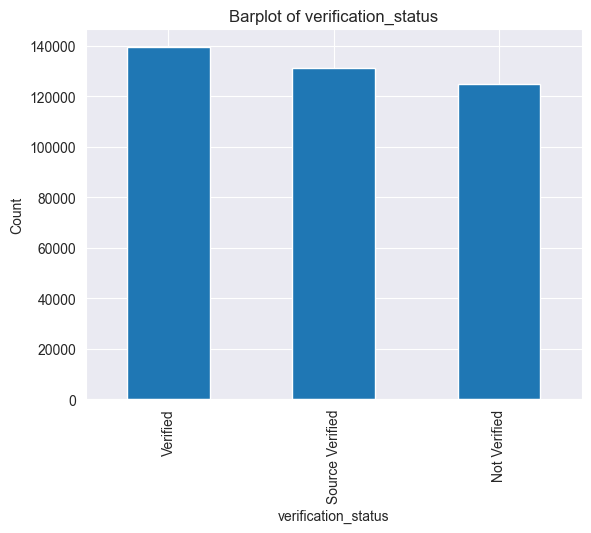

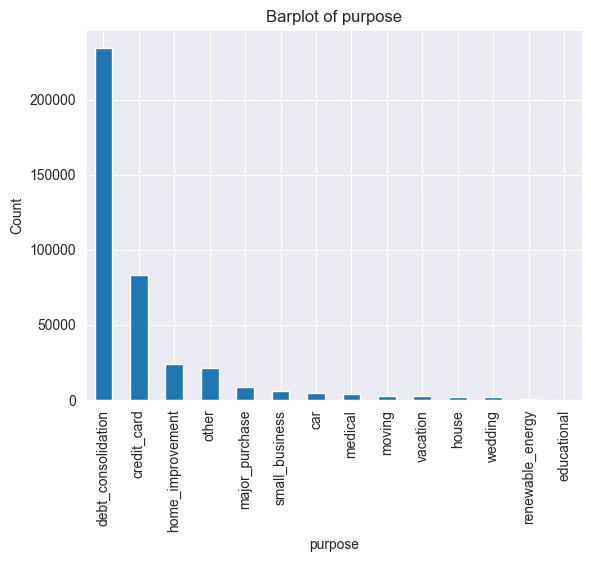

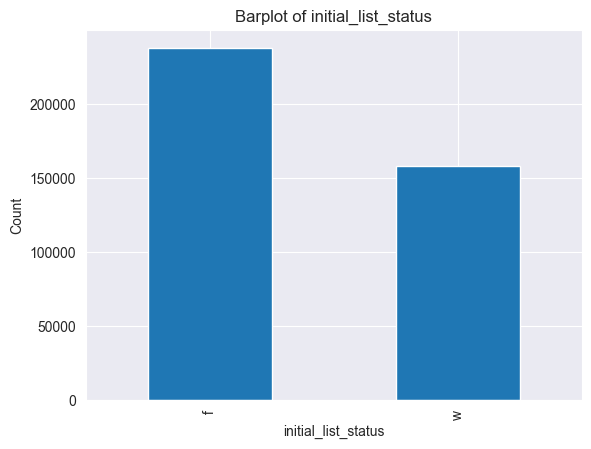

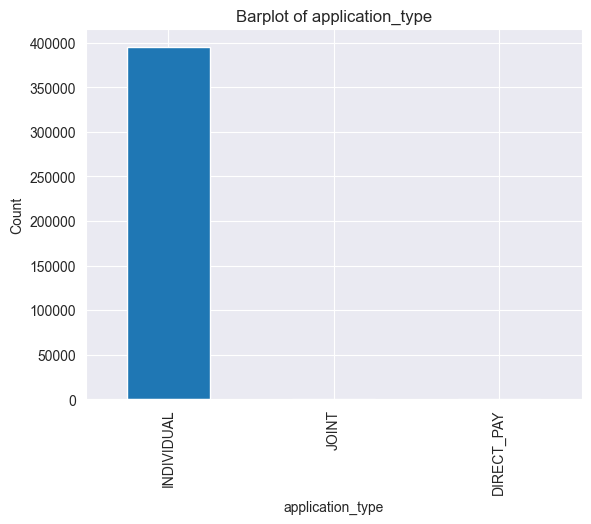

In [11]:
categorical = ['term','grade','sub_grade','home_ownership','verification_status', 'purpose','initial_list_status','application_type']

for col in categorical:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Barplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

Insights:
- Term: Most loans have a 36- month terms, indicating a preference for shorter repayment periods.
- Grade: Grades B, C and A are most common, reflecting generally good credit quality.
- Home Ownership: Majority of borrowers either have rent or have a mortgage, with few owning homes outright.
- Verification Status: Loan applications are fairly evenly split across all verification statuses.
- Purpose: Debt consolidation is the leading reason for taking loans, followed by credit card repayment.

## Bivariate Analysis

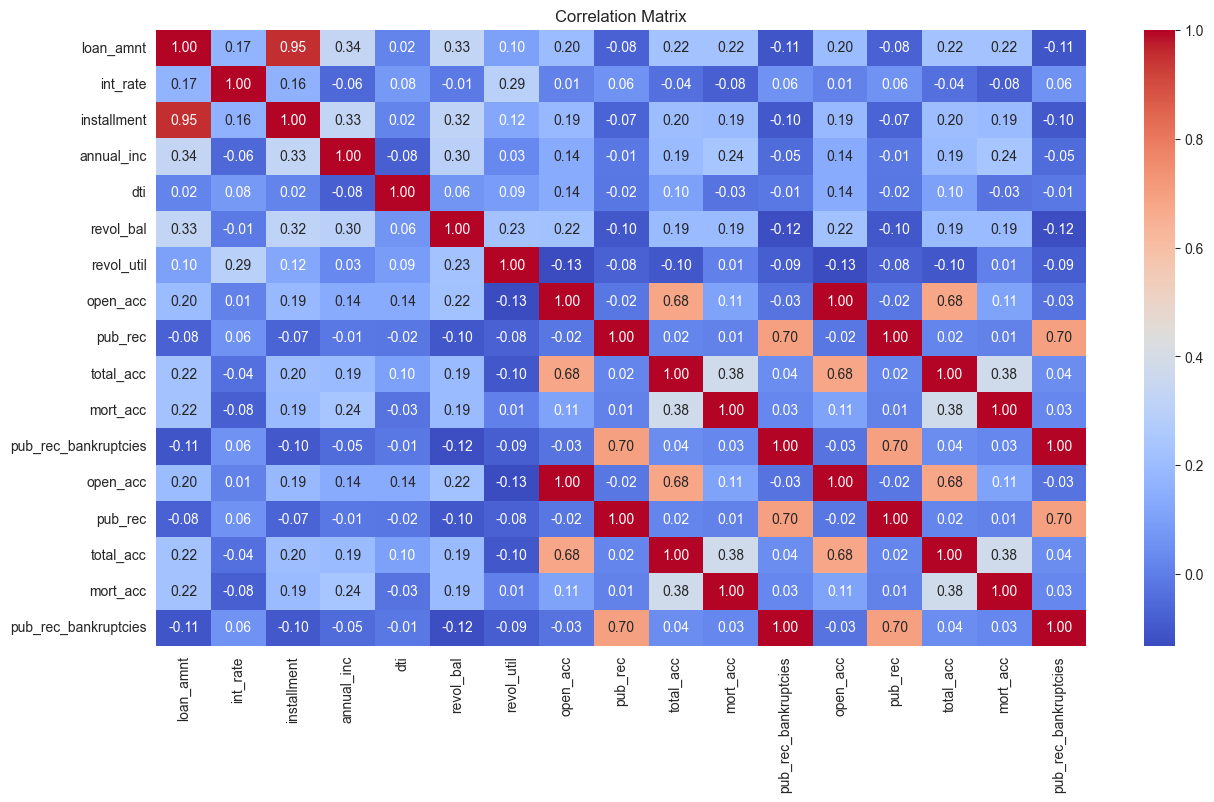

In [12]:
selected = continous + ['open_acc', 'pub_rec', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']

corr = df[selected].corr()
plt.figure(figsize = (15,8))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

Insights
- Loan Amount <-> Installment: Strong correlation (0.95) --> Higher Loan, Higher EMI.
- Annual Income <-> Loan Amount: Weak link (0.34) --> Income isn't a strong driver.
- Interest Rate: Low correlation with all - influenced by many factors.
- Most other features show low correlation - minimal multicollinearity.

## Comments on Ranges, Outliers & Distributions

- Ranges: annual_inc spans 0 to 8 million and dti spans 0 - 1000%.
- Outliers: A handful of borrowers report zero or near zero incomes.
- Distributions: Most continous features are right skewed; central limit assumptions may not hold.

# Data Preprocessing

## Duplicate Value Check

In [13]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


Insights:
Zero duplicates - no rows are exact copies

## Missing Value Treatment

In [14]:
df = df.drop(columns = ['emp_title', 'title', 'address', 'emp_length'])

df.fillna(0, inplace=True)

Insights:
Removed high cardinality text (hard to encode) and fill numeric gaps with 0, assuming no records.

## Outlier Treatment

In [15]:
cap = df['annual_inc'].quantile(0.99)
df['annual_inc'] = df['annual_inc'].clip(upper = cap)

Insights:
Capping reduces distortion from extreme high incomes.

## Feature Engineering

In [16]:
df['pub_rec_flag'] = (df['pub_rec'] > 1).astype(int)
df['mort_acc_flag'] = (df['mort_acc'] > 1).astype(int)
df['pub_rec_bankruptcies_flag'] = (df['pub_rec_bankruptcies'] > 1).astype(int)

Insights:
Binary flag captures presence of adverse records, simplifying numeric counts.

## Data Preparation for Modelling

In [17]:
categorical = ['term','grade','sub_grade','home_ownership','verification_status', 'purpose','initial_list_status','application_type']

df = pd.get_dummies(df, columns = categorical, drop_first = True)

In [18]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format = '%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format = '%b-%Y')

df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month
df['first_cr_year'] = df['earliest_cr_line'].dt.year
df['first_cr_month'] = df['earliest_cr_line'].dt.month

df = df.drop(columns = ['issue_d', 'earliest_cr_line'])

In [19]:
continous = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'issue_year', 'issue_month', 'first_cr_year', 'first_cr_month']

scaler = StandardScaler()
df[continous] = scaler.fit_transform(df[continous])

In [20]:
df['loan_status_flag'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

Insights:
All predictors are numeric and on comparable scales, target is binary.

## Data for Model Training

In [31]:
x = df.drop(columns = ['loan_status', 'loan_status_flag'])
y = df['loan_status_flag']

## Handling Class Imbalance

In [60]:
smote = SMOTE(sampling_strategy=1.0, random_state=42)
pipeline = Pipeline([('smote', smote)])

x_res, y_res = pipeline.fit_resample(x, y)
print("Resampled Distribution:\n", y_res.value_counts(normalize = True))

Resampled Distribution:
 loan_status_flag
0    0.5
1    0.5
Name: proportion, dtype: float64


## Train-Test Data Split

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size = 0.2, random_state = 42)

# Model Building

## Logistic Regression

In [63]:
model = LogisticRegression(max_iter = 2000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=2000)

## Threshold Tuning for Maximum F1

In [77]:
y_scores = model.predict_proba(x_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = np.array([f1_score(y_test, (y_scores >= t).astype(int)) for t in thresholds])

opt_idx = f1_scores.argmax()
opt_thresh = thresholds[opt_idx]
opt_f1 = f1_scores[opt_idx]

y_pred = (y_scores >= opt_thresh).astype(int)

print(f"Optimal Threshold = {opt_thresh:.2f}, F1-Score = {opt_f1:.3f}")

Optimal Threshold = 0.40, F1-Score = 0.764


Insights: We have shifted the default 0.40 to ~0.76, raising class 1 F1.

## Model Statistics & Coefficients

In [86]:
coef = pd.Series(model.coef_[0], index = x_train.columns)
top_coef = coef.abs().sort_values(ascending = False).head(10)
print(f"Top 10 features by |coefficient|:\n", top_coef)

Top 10 features by |coefficient|:
 sub_grade_B5               6.460943
sub_grade_B4               6.363280
home_ownership_RENT        6.360917
sub_grade_B3               6.217538
sub_grade_C5               6.196402
home_ownership_MORTGAGE    6.139157
sub_grade_C4               6.127561
sub_grade_B2               6.068870
sub_grade_C3               6.040662
sub_grade_C2               5.957149
dtype: float64


In [88]:
top_pos = coef.nlargest(10)
top_neg = coef.nsmallest(10)

print("Top Positives:\n", top_pos)
print("Top Negatives:\n", top_neg)

Top Positives:
 sub_grade_B5               6.460943
sub_grade_B4               6.363280
home_ownership_RENT        6.360917
sub_grade_B3               6.217538
sub_grade_C5               6.196402
home_ownership_MORTGAGE    6.139157
sub_grade_C4               6.127561
sub_grade_B2               6.068870
sub_grade_C3               6.040662
sub_grade_C2               5.957149
dtype: float64
Top Negatives:
 grade_B         -1.809766
grade_C         -1.039625
loan_amnt       -0.953102
int_rate        -0.361184
pub_rec_flag    -0.346652
annual_inc      -0.298047
mort_acc_flag   -0.280754
total_acc       -0.169273
grade_D         -0.120885
revol_bal       -0.095212
dtype: float64


Insights:
- Positive --> Default Risk
- Negative --> Safe:


# Result Evaluation

## Classification Report

In [80]:
print(classification_report(y_test, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.779     0.702     0.739     63643
           1      0.729     0.801     0.764     63700

    accuracy                          0.752    127343
   macro avg      0.754     0.752     0.751    127343
weighted avg      0.754     0.752     0.751    127343



Insights:
- Overall Model Performance: 75%

## ROC AUC Curve

ROC AUC = 0.852


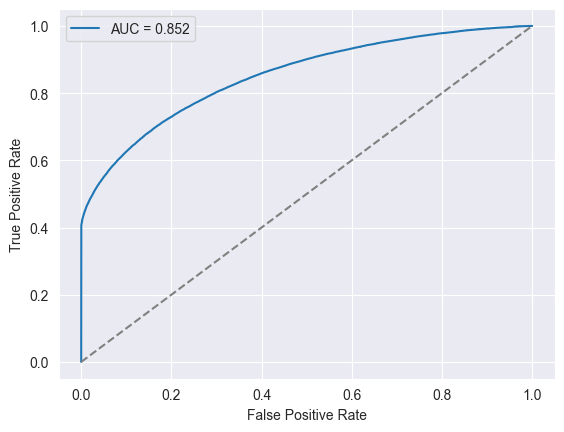

In [81]:
auc = roc_auc_score(y_test, y_scores)
print(f"ROC AUC = {auc:.3f}")

fpr, tpr, _ = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, label = f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], '--', color = 'grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Insights:
- AUC = ~0.85 the model districiminates well between paid vs default
- The ROC curve bows significantly above random, confirming robust overall performance.

## Precision - Recall Curve

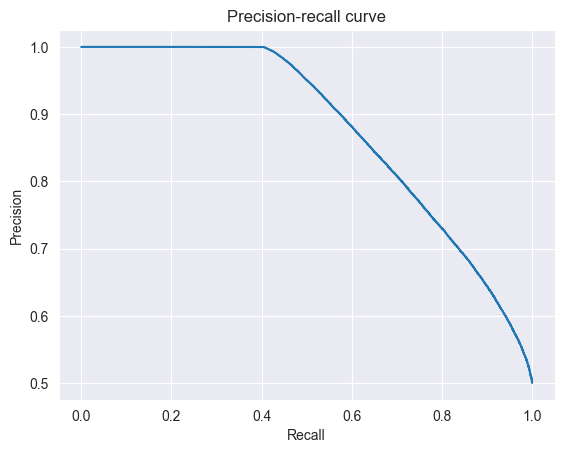

In [82]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)
plt.plot(recall, precision)
plt.title('Precision-recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

Insights:
- In the high recall region, precision stays around 0.4 - acceptable for a defaulter flagging system.

## Confusion Matrix

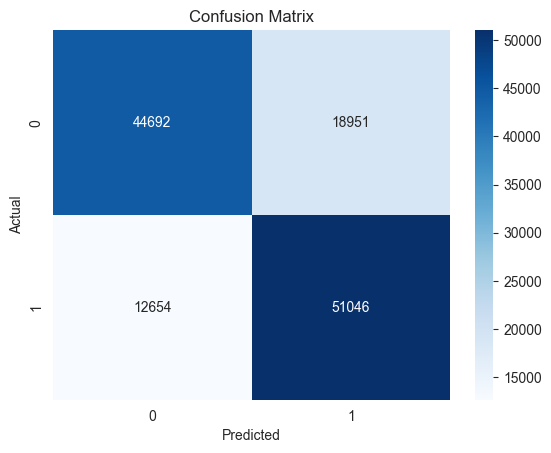

In [85]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Insights
- Defaulter detection is strong, caught 51,046 actual defaulters
- Moderate False Positives (18,951). Good customers wrongly flagged may lead to missed opportunities.
- Low Missed defaults (12,654 false negatives). Still room to improve, causes direct financial loss.
- True Negatives are solid (44,692). Model confidently approves low risk borrowers.

# Trade Off Questions

1. What percentage of customers have fully paid their loan amount? --> Approximately 80%, indicates class imbalance - Majority class is "Fully Paid".
2. Comment on correlation between Loan Amount and Installment --> High Positive correlation (~0.95), indicates larger loans require higher monthly payments.
3. The majority of people have home ownership as --> Mortgage. Many borrowers have ongoing home loans; relevant for assessing repayment capacity.
4. People with grade ‘A’ are more likely to fully pay their loan --> True. Grade A corresponds to low-risk customers. EDA confirms high repayment rates in Grade A.
5. Top 2 most common job titles --> Manager and teacher.
6. From a bank’s perspective, the primary metric should be --> recall. It’s critical to catch as many defaulters as possible to minimize NPA—even if some good customers are falsely flagged.
7. How does the gap in precision and recall affect the bank? --> High recall, low precision → many good customers flagged → lost business.
	•	High precision, low recall → missed defaulters → direct financial loss.
8. Top features that heavily affected the outcome --> int_rate, dti, pub_rec_flag, mort_acc_flag, pub_rec_bankruptcies_flag
9. Will results be affected by geographical location? --> No. Geolocation features like “Address” were not used in modeling — thus, predictions are geographically agnostic in this setup.